# Game of Thrones – Social Graphs Project (02805)

**Student: Bashar Bdewi (s183356)**

In this study, I analyze Season 1 of
the HBO series Game of Thrones using a joint network–and–text
pipeline from a public script dataset.
#### Research Question

In this project we ask:

> **How does the conversational network structure of Game of Thrones – Season 1 relate to what different character groups talk about and how “positive/negative” their language is?**

We combine **network analysis** (centralities, communities, backbone) with **classical NLP** (TF-IDF, wordclouds) and **dictionary-based sentiment analysis** (LabMT), and study how structural communities in the character graph map to narrative factions and emotional tone.

---



# 0. Setup 

In [3]:
# Import core libraries


# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
%matplotlib inline

# Network analysis
import networkx as nx
from collections import Counter
from itertools import combinations

# NLP (tokenization + stopwords)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# TF–IDF
from sklearn.feature_extraction.text import TfidfVectorizer


# Wordclouds
from wordcloud import WordCloud


# Community detection (Louvain)
import community as community_louvain  # python-louvain package


# Utilities for cleaning text / paths
import re
import string
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer



# Step 1.  Load dataset and Compute basic Season 1 stats

In this first step, we will:

1. Import the basic Python libraries.
2. Load the full script dataset: `Game_of_Thrones_Script.csv`.
3. Extract **Season 1** only.
4. Compute a few simple statistics that we will later reuse it.

## Load the full Game of Thrones script dataset

We use the file `Game_of_Thrones_Script.csv` as our main source of dialogue.
Each row corresponds to one spoken line in the show and contains:

- `Release Date`: Air date of the episode.
- `Season`: Season label (e.g. `"Season 1"`).
- `Episode`: Episode label (e.g. `"Episode 3"`).
- `Episode Title`: Name of the episode.
- `Name`: The speaking character.
- `Sentence`: The actual spoken line (text).



In [6]:
# Load the full script CSV


script_path = "../data/Game_of_Thrones_Script.csv"


# Read the CSV into a DataFrame
script_df = pd.read_csv(script_path)

# Show the first 5 rows to inspect the structure
script_df.head()


,Release Date,Season,Episode,Episode Title,Name,Sentence
0,2011-04-17,Season 1,Episode 1,Winter is Coming,waymar royce,What do you expect? They're savages. One lot s...
1,2011-04-17,Season 1,Episode 1,Winter is Coming,will,I've never seen wildlings do a thing like this...
2,2011-04-17,Season 1,Episode 1,Winter is Coming,waymar royce,How close did you get?
3,2011-04-17,Season 1,Episode 1,Winter is Coming,will,Close as any man would.
4,2011-04-17,Season 1,Episode 1,Winter is Coming,gared,We should head back to the wall.


In [7]:
script_df.columns

Index(['Release Date', 'Season', 'Episode', 'Episode Title', 'Name',
       'Sentence'],
      dtype='object')

## Extract Season 1 only

For this project we start by focusing on **Season 1**.

Later, we might extend to more seasons, buth aving a clean Season 1 subset makes it easier to:
  - build the character interaction network,
  - compute centralities and communities,
  - and run TF–IDF + sentiment analysis in a controlled setting.


In [9]:
# Filter Season 1

# Keep only rows where the "Season" column is exactly "Season 1"
s1_df = script_df[script_df["Season"] == "Season 1"].copy()

# Inspect the first rows
s1_df.head()


,Release Date,Season,Episode,Episode Title,Name,Sentence
0,2011-04-17,Season 1,Episode 1,Winter is Coming,waymar royce,What do you expect? They're savages. One lot s...
1,2011-04-17,Season 1,Episode 1,Winter is Coming,will,I've never seen wildlings do a thing like this...
2,2011-04-17,Season 1,Episode 1,Winter is Coming,waymar royce,How close did you get?
3,2011-04-17,Season 1,Episode 1,Winter is Coming,will,Close as any man would.
4,2011-04-17,Season 1,Episode 1,Winter is Coming,gared,We should head back to the wall.


In [10]:
len(s1_df)

3179

## Basic statistics for Season 1

we compute:

- The number of dialogue lines in Season 1.
- The number of episodes in Season 1.
- The number of *unique speaking characters* in Season 1.

We also print a small breakdown of how many lines appear in each episode.


In [12]:
# Compute basic Season 1 stats

# Total number of dialogue lines (rows)
n_lines = len(s1_df)

# Number of unique episodes
n_episodes = s1_df["Episode"].nunique()

# Number of unique speaking characters
n_characters = s1_df["Name"].nunique()

print("=== Game of Thrones – Season 1 (Script Stats) ===")
print(f"Number of dialogue lines : {n_lines}")
print(f"Number of episodes       : {n_episodes}")
print(f"Number of unique speakers: {n_characters}")

# Lines per episode (just to see the distribution)
lines_per_episode = s1_df.groupby("Episode")["Sentence"].count().sort_index()

print("\nLines per episode:")
print(lines_per_episode)


=== Game of Thrones – Season 1 (Script Stats) ===
Number of dialogue lines : 3179
Number of episodes       : 10
Number of unique speakers: 146

Lines per episode:
Episode
Episode 1     327
Episode 10    266
Episode 2     283
Episode 3     353
Episode 4     404
Episode 5     432
Episode 6     297
Episode 7     249
Episode 8     201
Episode 9     367
Name: Sentence, dtype: int64


## Visualize lines per episode (Season 1)

As a first simple figure, we create a bar chart that shows:

- On the x-axis: episodes in Season 1.
- On the y-axis: the number of dialogue lines in each episode.



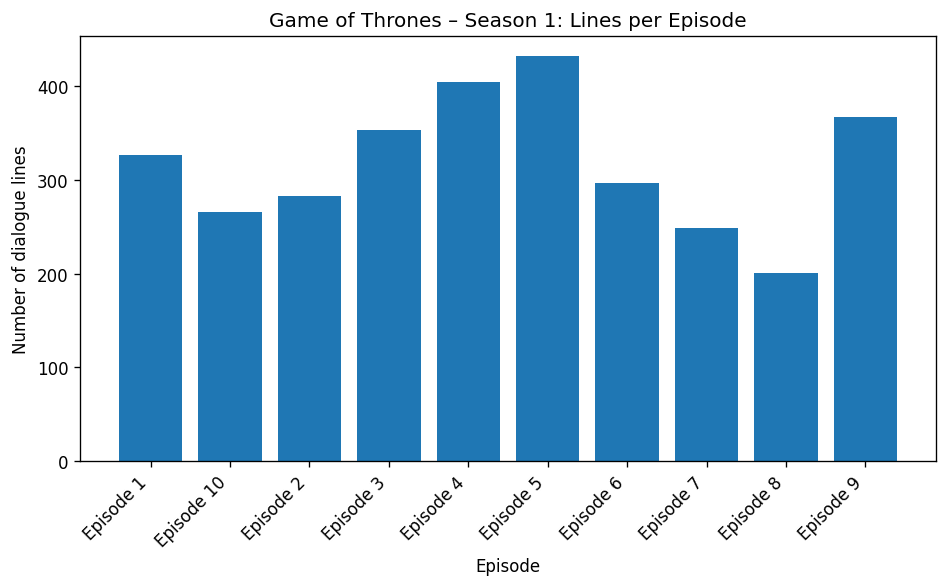

In [14]:
# Plot lines per episode for Season 1

lines_per_episode = s1_df.groupby("Episode")["Sentence"].count().sort_index()

plt.bar(lines_per_episode.index, lines_per_episode.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Episode", fontsize=10)
plt.ylabel("Number of dialogue lines", fontsize=10)
plt.title("Game of Thrones – Season 1: Lines per Episode", fontsize=12)
plt.tight_layout()
plt.show()


## Save a clean Season 1 script subset

To make our analysis reproducible, we save the Season 1 subset to a separate file:

- File name: `got_season1_script_clean.csv`

Later notebooks (network construction, TF–IDF, sentiment) can directly load this file,
instead of re-filtering from the full script again.


In [16]:
# Save Season 1 subset to CSV

output_path = "../data/got_season1_script_clean.csv"

s1_df.to_csv(output_path, index=False)

print(f"Saved Season 1 script subset to: {output_path}")


Saved Season 1 script subset to: ../data/got_season1_script_clean.csv


## STEP 2 – Build the Season 1 character interaction network

In this step we convert the Season 1 script into a **character network**.

- Each **node** = a speaking character.
- Each **edge** = an interaction between two consecutive speakers.
- The **weight** of an edge = how many times this pair of characters speak in sequence.

This gives us:
- A clean `nodes` table.
- A clean `edges` table.
- A NetworkX graph object.


In [18]:
# Ensure we have the Season 1 script loaded

try:
    # If we already have s1_df from Step 1, this will succeed
    s1_df
    print("Using existing s1_df from memory.")
except NameError:
    # If the notebook was restarted, reload from the cleaned CSV
    print("s1_df not found in memory – loading from 'got_season1_script_clean.csv'...")
    s1_df = pd.read_csv("got_season1_script_clean.csv")

# Quick check
print("Season 1 rows:", len(s1_df))
s1_df.head()


Using existing s1_df from memory.
Season 1 rows: 3179


,Release Date,Season,Episode,Episode Title,Name,Sentence
0,2011-04-17,Season 1,Episode 1,Winter is Coming,waymar royce,What do you expect? They're savages. One lot s...
1,2011-04-17,Season 1,Episode 1,Winter is Coming,will,I've never seen wildlings do a thing like this...
2,2011-04-17,Season 1,Episode 1,Winter is Coming,waymar royce,How close did you get?
3,2011-04-17,Season 1,Episode 1,Winter is Coming,will,Close as any man would.
4,2011-04-17,Season 1,Episode 1,Winter is Coming,gared,We should head back to the wall.


### Clean speaker names and keep only dialogue rows

Not all rows have a valid speaking character (some may have `NaN` in `Name`).

Here we Drop rows where `Name` is missing and Create a cleaned `Speaker` column and Keep only the columns we care about for building the interaction network:
   - `Season`, `Episode`, `Episode Title`, `Speaker`, `Sentence`.


In [20]:
# Clean speaker names and create a Speaker column

# Drop rows with missing speaker names
dialogue_df = s1_df.dropna(subset=["Name"]).copy()

# Create a cleaned Speaker column
dialogue_df["Speaker"] = (
    dialogue_df["Name"]
    .astype(str)
    .str.strip()
    .str.lower()          # normalize case
    .str.replace(r"\s+", " ", regex=True)  # collapse multiple spaces
    .str.title()          # nice formatting, e.g. "eddard stark" -> "Eddard Stark"
)

# Keep only the relevant columns for now
dialogue_df = dialogue_df[["Season", "Episode", "Episode Title", "Speaker", "Sentence"]]

print("Number of dialogue lines with a valid speaker:", len(dialogue_df))
dialogue_df.head(10)


Number of dialogue lines with a valid speaker: 3179


,Season,Episode,Episode Title,Speaker,Sentence
0,Season 1,Episode 1,Winter is Coming,Waymar Royce,What do you expect? They're savages. One lot s...
1,Season 1,Episode 1,Winter is Coming,Will,I've never seen wildlings do a thing like this...
2,Season 1,Episode 1,Winter is Coming,Waymar Royce,How close did you get?
3,Season 1,Episode 1,Winter is Coming,Will,Close as any man would.
4,Season 1,Episode 1,Winter is Coming,Gared,We should head back to the wall.
5,Season 1,Episode 1,Winter is Coming,Royce,Do the dead frighten you?
6,Season 1,Episode 1,Winter is Coming,Gared,Our orders were to track the wildlings. We tra...
7,Season 1,Episode 1,Winter is Coming,Royce,You don't think he'll ask us how they died? Ge...
8,Season 1,Episode 1,Winter is Coming,Will,Whatever did it to them could do it to us. The...
9,Season 1,Episode 1,Winter is Coming,Royce,It's a good thing we're not children. You want...


### Build edges from consecutive dialogue lines

We approximate interactions like this:

- If Character A speaks and the **next line** in the same episode is spoken by Character B, then we add a directed interaction A → B.

Later we will aggregate all these (A, B) pairs and count how many times they occur,
so the final edges will be **weighted**.



In [22]:
# Create raw Source → Target edges from consecutive lines

# For each episode, we add the next speaker as "NextSpeaker"
dialogue_df["NextSpeaker"] = dialogue_df.groupby("Episode")["Speaker"].shift(-1)

# Define source and target
edges_raw = dialogue_df[["Episode", "Speaker", "NextSpeaker"]].copy()
edges_raw.rename(columns={"Speaker": "Source", "NextSpeaker": "Target"}, inplace=True)

# Drop rows where Target is missing (last line of each episode)
edges_raw = edges_raw.dropna(subset=["Target"])

# drop self-loops (character speaking twice in a row)
edges_raw = edges_raw[edges_raw["Source"] != edges_raw["Target"]]

print("Raw edges (before aggregation):", len(edges_raw))
edges_raw.head(15)


Raw edges (before aggregation): 3039


,Episode,Source,Target
0,Episode 1,Waymar Royce,Will
1,Episode 1,Will,Waymar Royce
2,Episode 1,Waymar Royce,Will
3,Episode 1,Will,Gared
4,Episode 1,Gared,Royce
5,Episode 1,Royce,Gared
6,Episode 1,Gared,Royce
7,Episode 1,Royce,Will
8,Episode 1,Will,Royce
10,Episode 1,Royce,Will


### Aggregate edges and compute weights

Now we turn the raw transitions into a proper edge list:

- Each row = one ordered pair (Source, Target).
- `weight` = number of times this pair appears across Season 1.

We also sort edges by `weight` so that the strongest relationships appear at the top.


In [24]:
# Aggregate edges by (Source, Target) and count weights

edges_grouped = (
    edges_raw
    .groupby(["Source", "Target"])
    .size()
    .reset_index(name="weight")
    .sort_values(by="weight", ascending=False)
    .reset_index(drop=True)
)

print("Number of unique directed edges:", len(edges_grouped))
edges_grouped.head(20)


Number of unique directed edges: 723


,Source,Target,weight
0,Robert Baratheon,Eddard Stark,55
1,Eddard Stark,Robert Baratheon,53
2,Daenerys Targaryen,Jorah Mormont,40
3,Petyr Baelish,Eddard Stark,39
4,Jorah Mormont,Daenerys Targaryen,37
5,Sam Tarly,Jon Snow,36
6,Eddard Stark,Petyr Baelish,34
7,Arya Stark,Eddard Stark,32
8,Jon Snow,Sam Tarly,31
9,Eddard Stark,Cersei Lannister,30


### Build the nodes table (characters)

We need a separate **nodes table** for:

- Loading the network in Gephi,
- describing the dataset in the project,
- and adding node-level attributes later (e.g. communities, centrality, sentiment).




In [26]:
# Build the nodes DataFrame 


# All nodes = union of all sources and targets from the aggregated edge list
all_sources = edges_grouped["Source"].unique()
all_targets = edges_grouped["Target"].unique()
all_nodes = np.union1d(all_sources, all_targets)

# Create base nodes_df with id + label
nodes_df = pd.DataFrame({"id": all_nodes})
nodes_df["label"] = nodes_df["id"]

# Count how many lines each character speaks in Season 1
# (this does not depend on index names, just on the "Speaker" column)
lines_per_speaker = (
    dialogue_df
    .groupby("Speaker")
    .size()
    .reset_index(name="n_lines")   # columns: ["Speaker", "n_lines"]
)

# Rename Speaker → id so we can merge easily
lines_per_speaker.rename(columns={"Speaker": "id"}, inplace=True)

# Merge counts into nodes_df
nodes_df = nodes_df.merge(lines_per_speaker, on="id", how="left")

# Replace NaN with 0 and ensure integer type
nodes_df["n_lines"] = nodes_df["n_lines"].fillna(0).astype(int)

print("Number of nodes (characters):", len(nodes_df))
print(nodes_df.head(15))
print("\nnodes_df columns:", nodes_df.columns.tolist())


Number of nodes (characters): 146
                  id             label  n_lines
0            A Voice           A Voice        1
1     Addam Marbrand    Addam Marbrand        2
2                All               All        2
3     Alliser Thorne    Alliser Thorne       13
4         Arya Stark        Arya Stark      102
5           Assassin          Assassin        1
6    Barristan Selmy   Barristan Selmy       22
7          Barriston         Barriston        1
8             Benjen            Benjen       12
9       Benjen Stark      Benjen Stark       13
10  Beric Dondarrion  Beric Dondarrion        1
11        Bran Stark        Bran Stark       62
12             Bronn             Bronn       33
13            Cassel            Cassel        3
14     Catelyn Stark     Catelyn Stark      138

nodes_df columns: ['id', 'label', 'n_lines']


### Build a NetworkX graph and compute basic stats

Now we use the `edges_grouped` and `nodes_df` to build a graph:

- We use an **undirected** graph for now.
- We attach `weight` to each edge.

We then compute:

- number of nodes,
- number of edges,
- graph density,
- number of connected components,
- size of the largest connected component.


In [28]:
# Build the NetworkX graph and compute basic stats


# Create an undirected graph
G_s1 = nx.Graph()

# Add nodes with attributes
for _, row in nodes_df.iterrows():
    G_s1.add_node(row["id"], label=row["label"], n_lines=row["n_lines"])

# Add edges with weight
for _, row in edges_grouped.iterrows():
    src = row["Source"]
    tgt = row["Target"]
    w = row["weight"]
    # If edge already exists, sum weights (just in case)
    if G_s1.has_edge(src, tgt):
        G_s1[src][tgt]["weight"] += w
    else:
        G_s1.add_edge(src, tgt, weight=w)

# Basic stats
n_nodes = G_s1.number_of_nodes()
n_edges = G_s1.number_of_edges()
density = nx.density(G_s1)
n_components = nx.number_connected_components(G_s1)

# Largest connected component size
largest_cc = max(nx.connected_components(G_s1), key=len)
size_lcc = len(largest_cc)

print("=== Season 1 Character Interaction Network ===")
print(f"Number of nodes                : {n_nodes}")
print(f"Number of edges                : {n_edges}")
print(f"Density                        : {density:.4f}")
print(f"Number of connected components : {n_components}")
print(f"Largest connected component    : {size_lcc} nodes")


=== Season 1 Character Interaction Network ===
Number of nodes                : 146
Number of edges                : 482
Density                        : 0.0455
Number of connected components : 1
Largest connected component    : 146 nodes


In [29]:
print(G_s1.number_of_nodes(), len(nodes_df))
print(G_s1.number_of_edges(), len(edges_grouped))


146 146
482 723


### plot the network

This is **not** our final visualization (we will probably use Gephi with ForceAtlas2),
but a small NetworkX preview is useful to check that:

- The network looks reasonable.
- There is one big component and maybe a few tiny components.
- The main characters are roughly in the center of the graph.

We size nodes by their degree and use a simple spring layout.


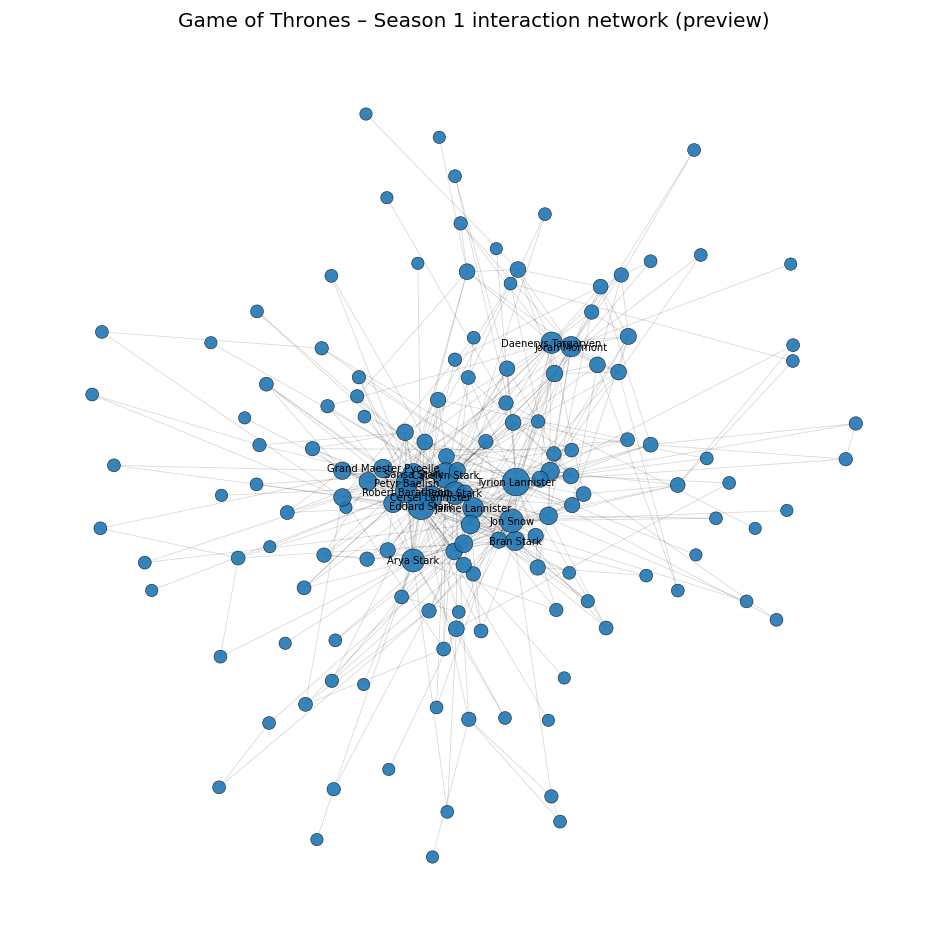

In [31]:
# Quick NetworkX preview plot

# 1) Degrees + node sizes
degree_dict = dict(G_s1.degree())
node_sizes = [50 + 5 * degree_dict[n] for n in G_s1.nodes()]  # slightly scale size by degree

# 2) Spring layout (fixed seed so layout is stable across runs)
pos = nx.spring_layout(G_s1, seed=42, k=0.5)

# 3) Show labels only for top-degree characters (to avoid a hairball of names)
TOP_N = 15
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
top_nodes = [n for n, _ in top_nodes]
labels = {n: n for n in top_nodes}

# ---------- (A) Quick on-screen preview ----------
plt.figure(figsize=(8, 8))

nx.draw_networkx_nodes(
    G_s1,
    pos,
    node_size=node_sizes,
    node_color="tab:blue",
    alpha=0.9,
    edgecolors="black",
    linewidths=0.3,
)

nx.draw_networkx_edges(
    G_s1,
    pos,
    alpha=0.15,
    width=0.5
)

nx.draw_networkx_labels(
    G_s1,
    pos,
    labels=labels,
    font_size=6,          # smaller labels
    font_weight="normal"  # not bold
)

plt.title("Game of Thrones – Season 1 interaction network (preview)")
plt.axis("off")
plt.tight_layout()
plt.show()




### Save nodes, edges, and GraphML for later use




In [33]:
# Save nodes, edges, and GraphML

nodes_path    = "../data/got_s1_nodes.csv"
edges_path    = "../data/got_s1_edges.csv"
graphml_path  = "../data/got_s1_network.graphml"


nodes_df.to_csv(nodes_path, index=False)
edges_grouped.to_csv(edges_path, index=False)

nx.write_graphml(G_s1, graphml_path)

print("Saved:")
print(f"- Nodes  → {nodes_path}")
print(f"- Edges  → {edges_path}")
print(f"- Graph  → {graphml_path}")


Saved:
- Nodes  → ../data/got_s1_nodes.csv
- Edges  → ../data/got_s1_edges.csv
- Graph  → ../data/got_s1_network.graphml


# Step 2 – Basic stats per character (degree & top characters)

In this step we want a **simple overview** of the Season 1
character network:

- For each character (node) we compute their **degree**  
  → how many distinct other characters they directly interact with.
- We collect these degrees in a `DataFrame`.
- We sort to find the **top characters** by degree.



In [35]:
# ---------------------------------------------------
# Compute degree for each character
# ---------------------------------------------------
# degree_dict: {node_name: degree}
degree_dict = dict(G_s1.degree())

# Put degrees into a tidy DataFrame
nodes_stats = (
    pd.DataFrame.from_dict(degree_dict, orient="index", columns=["degree"])
    .reset_index()
    .rename(columns={"index": "character"})
)

print("First rows of per-character stats:")
display(nodes_stats.head())


First rows of per-character stats:


,character,degree
0,A Voice,2
1,Addam Marbrand,3
2,All,4
3,Alliser Thorne,9
4,Arya Stark,28


In [36]:
# ---------------------------------------------------
# Sort characters by degree (descending)
# ---------------------------------------------------
nodes_stats_sorted = nodes_stats.sort_values("degree", ascending=False)

print("\nTop 10 characters by degree (Season 1):")
display(nodes_stats_sorted.head(10))

# Optional: quick numeric summary of the degree distribution
print("\nDegree distribution summary:")
print(nodes_stats["degree"].describe())



Top 10 characters by degree (Season 1):


,character,degree
132,Tyrion Lannister,45
20,Eddard Stark,42
14,Catelyn Stark,36
41,Jon Snow,30
4,Arya Stark,28
99,Robb Stark,27
15,Cersei Lannister,26
100,Robert Baratheon,23
111,Sansa Stark,23
17,Daenerys Targaryen,23



Degree distribution summary:
count    146.000000
mean       6.602740
std        7.961528
min        1.000000
25%        2.000000
50%        4.000000
75%        8.000000
max       45.000000
Name: degree, dtype: float64


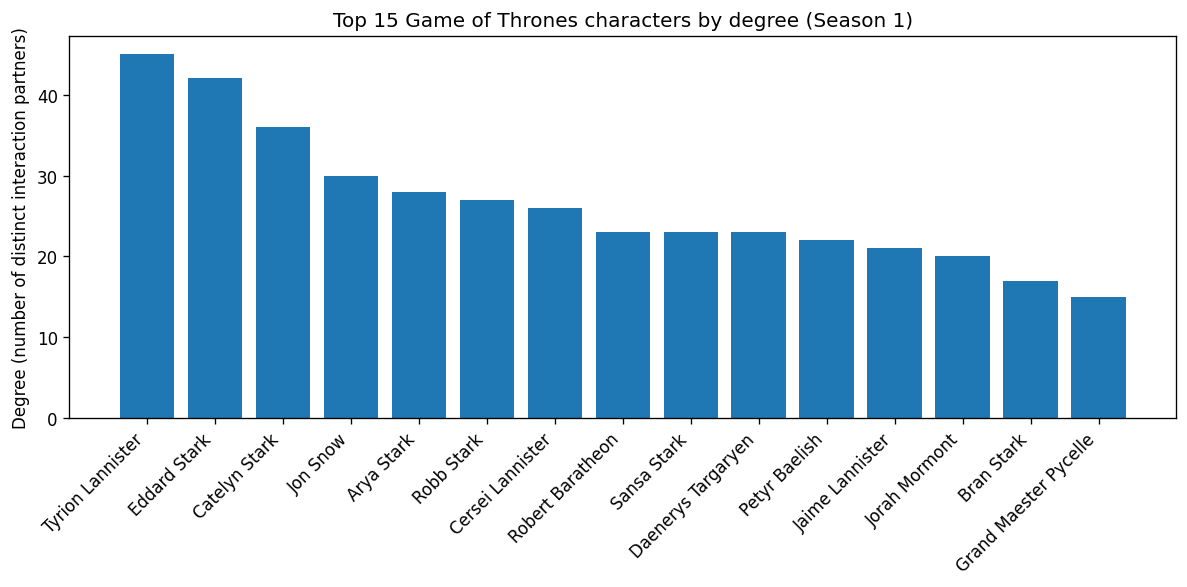

In [37]:
# ---------------------------------------------------
# Bar plot for top 15 characters
# ---------------------------------------------------
top_n = 15
top_chars = nodes_stats_sorted.head(top_n)

plt.figure(figsize=(10, 5))
plt.bar(top_chars["character"], top_chars["degree"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Degree (number of distinct interaction partners)")
plt.title("Top 15 Game of Thrones characters by degree (Season 1)")
plt.tight_layout()
plt.show()


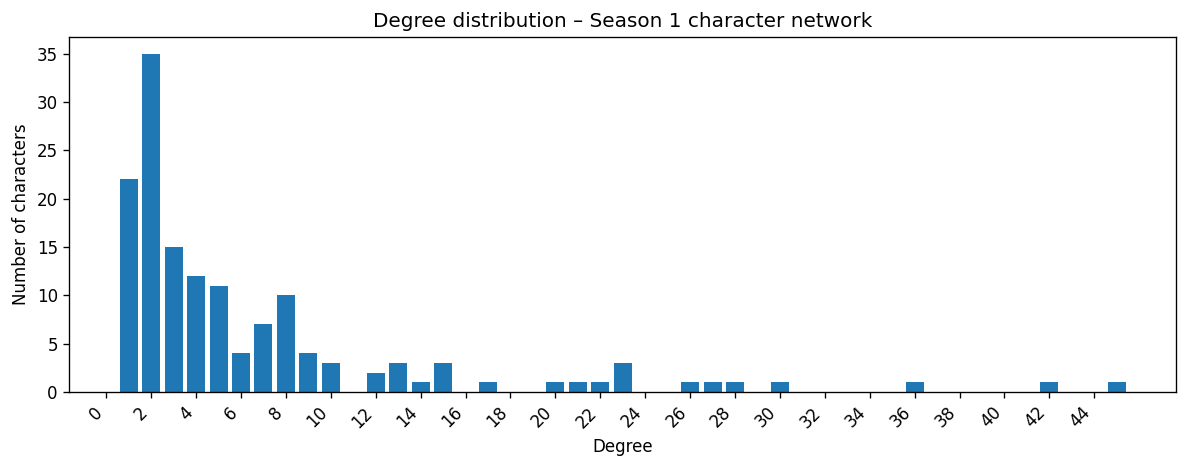

In [38]:
# ---------------------------------------------------
# Degree distribution histogram
# ---------------------------------------------------


# 1) Compute degrees of all nodes in the Season 1 graph
degrees = [d for _, d in G_s1.degree()]

# 2) Count how many characters have each degree
degree_counts = pd.Series(degrees).value_counts().sort_index()

# 3) Plot degree distribution
plt.figure(figsize=(10, 4))

plt.bar(degree_counts.index, degree_counts.values)
plt.xlabel("Degree")
plt.ylabel("Number of characters")
plt.title("Degree distribution – Season 1 character network")

# 4) Make x-axis labels less crowded
max_deg = degree_counts.index.max()

# show a tick every 2 degrees 
step = 2
xticks = np.arange(0, max_deg + 1, step)
plt.xticks(xticks, rotation=45, ha="right")

plt.tight_layout()
plt.show()


# Step 3 – Centralities of Season 1 character network

In this step we measure **which characters are structurally most important** in the
Season 1 interaction network `G_s1`.

We will use three classic centrality measures:

1. **Degree centrality**
     
     > How many *different* characters this character directly interacts with.
 
     - High degree centrality ⇒ the character talks to many others  
       → socially very visible / “hub” of interactions.

<br>

2. **Betweenness centrality**
   
     > How often this character lies on shortest paths between other pairs of characters.
 
     - High betweenness ⇒ important *broker* or *bridge* between groups  
       → can control or mediate information / conflicts between different houses.

<br>

3. **Eigenvector centrality**
    
     > A character is important if they are connected to other important characters.
    
     - High eigenvector ⇒ part of the *core elite* of the network  
       → connected to other central figures rather than only minor characters.




In [40]:
# Compute and inspect centralities for Season 1
# -----------------------------------------------

# Degree centrality: fraction of nodes each character is connected to
deg_cent = nx.degree_centrality(G_s1)

# Betweenness centrality: how often a node lies on shortest paths
bet_cent = nx.betweenness_centrality(G_s1, normalized=True)

# Eigenvector centrality: importance of a node based on neighbours' importance
eig_cent = nx.eigenvector_centrality(G_s1, max_iter=1000)

# Put them together into one DataFrame:
centrality_df = (
    pd.DataFrame.from_dict(deg_cent, orient="index", columns=["degree_centrality"])
      .assign(
          betweenness_centrality=pd.Series(bet_cent),
          eigenvector_centrality=pd.Series(eig_cent),
      )
      .reset_index()
      .rename(columns={"index": "id"})       # 'id' = character name
)

# Merge into nodes_df 
nodes_df = nodes_df.merge(centrality_df, on="id", how="left")



In [41]:
# function to show top-10 characters for a centrality
# -----------------------------------------------------------------

def show_top_10(cent_col, title):
    """
    Print a small table of the top 10 characters according to the
    chosen centrality column (e.g. 'degree_centrality').
    """
    display(
        nodes_df[["id", cent_col]]
        .sort_values(cent_col, ascending=False)
        .head(10)
        .reset_index(drop=True)
        .rename(columns={"id": "character"})
    )
    print(f"↑ Top 10 characters by {title}\n")


print("=== Top 10 by DEGREE centrality ===")
show_top_10("degree_centrality", "degree centrality")

print("=== Top 10 by BETWEENNESS centrality ===")
show_top_10("betweenness_centrality", "betweenness centrality")

print("=== Top 10 by EIGENVECTOR centrality ===")
show_top_10("eigenvector_centrality", "eigenvector centrality")

=== Top 10 by DEGREE centrality ===


,character,degree_centrality
0,Tyrion Lannister,0.310345
1,Eddard Stark,0.289655
2,Catelyn Stark,0.248276
3,Jon Snow,0.206897
4,Arya Stark,0.193103
5,Robb Stark,0.186207
6,Cersei Lannister,0.179310
7,Robert Baratheon,0.158621
8,Sansa Stark,0.158621
9,Daenerys Targaryen,0.158621


↑ Top 10 characters by degree centrality

=== Top 10 by BETWEENNESS centrality ===


,character,betweenness_centrality
0,Tyrion Lannister,0.210322
1,Eddard Stark,0.156039
2,Catelyn Stark,0.148555
3,Jon Snow,0.144942
4,Arya Stark,0.105675
5,Robb Stark,0.102680
6,Jorah Mormont,0.070538
7,Daenerys Targaryen,0.063521
8,Jeor Mormont,0.061821
9,Cersei Lannister,0.048692


↑ Top 10 characters by betweenness centrality

=== Top 10 by EIGENVECTOR centrality ===


,character,eigenvector_centrality
0,Eddard Stark,0.291248
1,Tyrion Lannister,0.262598
2,Catelyn Stark,0.261769
3,Cersei Lannister,0.236125
4,Petyr Baelish,0.229707
5,Jaime Lannister,0.221417
6,Jon Snow,0.219583
7,Robert Baratheon,0.211893
8,Robb Stark,0.210765
9,Sansa Stark,0.209715


↑ Top 10 characters by eigenvector centrality



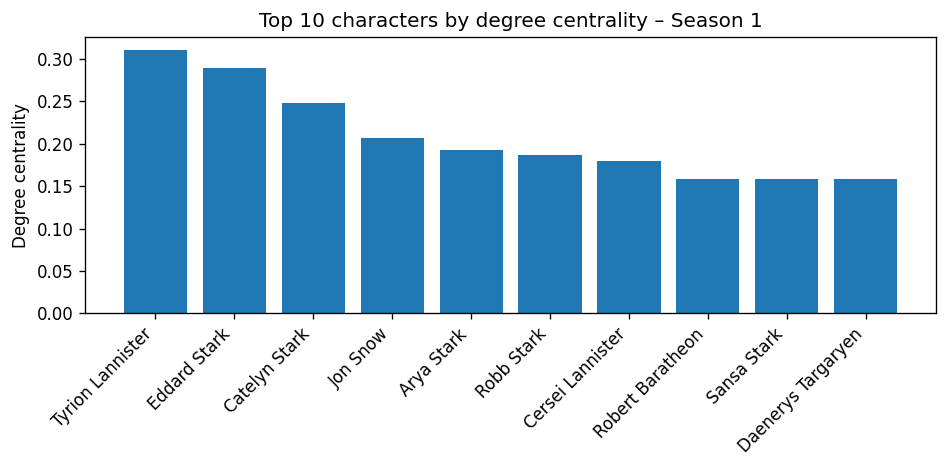

In [42]:
# Simple bar plot for degree centrality (top 10)
# ---------------------------------------------------------

top_deg = (
    nodes_df[["id", "degree_centrality"]]
    .sort_values("degree_centrality", ascending=False)
    .head(10)
)

# Use integer positions for x, then map them to names
x = np.arange(len(top_deg))

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x, top_deg["degree_centrality"])

ax.set_xticks(x)
ax.set_xticklabels(top_deg["id"], rotation=45, ha="right")

ax.set_ylabel("Degree centrality")
ax.set_title("Top 10 characters by degree centrality – Season 1")

fig.tight_layout()

# Save for the LaTeX report
fig.savefig("../report/fig_degree_centrality.pdf", dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)


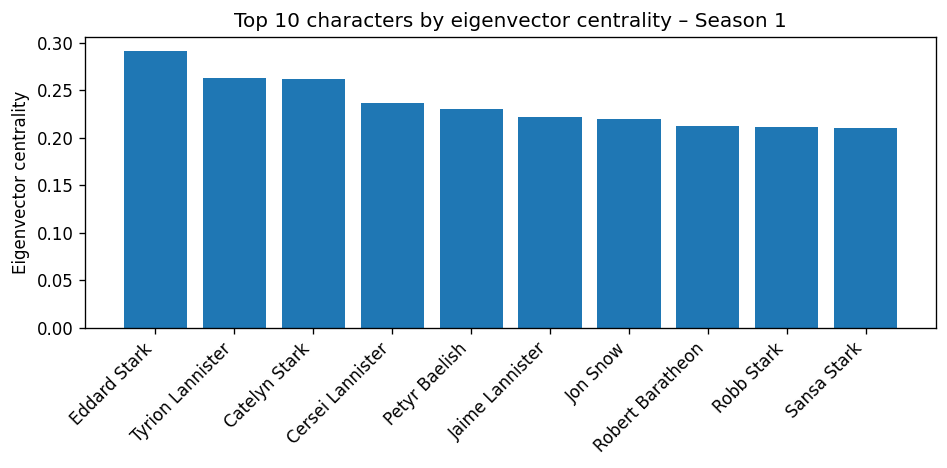

In [43]:
# Simple bar plot for eigenvector centrality (top 10)
# ---------------------------------------------------------

top_eig = (
    nodes_df[["id", "eigenvector_centrality"]]
    .sort_values("eigenvector_centrality", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.bar(top_eig["id"], top_eig["eigenvector_centrality"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Eigenvector centrality")
plt.title("Top 10 characters by eigenvector centrality – Season 1")
plt.tight_layout()
plt.show()

In [44]:


# nodes_df must contain:
# 'id', 'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality'

top_deg  = nodes_df[["id", "degree_centrality"]]     .sort_values("degree_centrality", ascending=False).head(10)
top_bet  = nodes_df[["id", "betweenness_centrality"]].sort_values("betweenness_centrality", ascending=False).head(10)
top_eig2 = nodes_df[["id", "eigenvector_centrality"]].sort_values("eigenvector_centrality", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=False)

# X positions
x_deg  = range(len(top_deg))
x_bet  = range(len(top_bet))
x_eig2 = range(len(top_eig2))

# (A) Degree
axes[0].bar(x_deg, top_deg["degree_centrality"])
axes[0].set_title("Degree", fontsize=10)
axes[0].set_xticks(x_deg)
axes[0].set_xticklabels(top_deg["id"], rotation=60, ha="right", fontsize=6)
axes[0].set_ylabel("Centrality")

# (B) Betweenness
axes[1].bar(x_bet, top_bet["betweenness_centrality"])
axes[1].set_title("Betweenness", fontsize=10)
axes[1].set_xticks(x_bet)
axes[1].set_xticklabels(top_bet["id"], rotation=60, ha="right", fontsize=6)

# (C) Eigenvector
axes[2].bar(x_eig2, top_eig2["eigenvector_centrality"])
axes[2].set_title("Eigenvector", fontsize=10)
axes[2].set_xticks(x_eig2)
axes[2].set_xticklabels(top_eig2["id"], rotation=60, ha="right", fontsize=6)

fig.suptitle("Top 10 characters by centrality – Season 1", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("../report/fig_centralities.pdf", dpi=300, bbox_inches="tight")
plt.close(fig)




In the rest of the project, we will reuse these scores when:
- Studying **communities** (who is central inside each module?),
- Linking to **text analysis** (topics and sentiments of high-centrality characters),
- when we discuss the overall **power structure** of Season 1.


# STEP 4 – Communities and backbone (Louvain + simple weighted backbone)

In this step we connect our network to:
- Community detection (Louvain, modularity)
- Backbone extraction (keep only the strongest links)




In [47]:
# ---------------------------------------------------------
# Recompute (or reuse) centralities
# ---------------------------------------------------------

# Degree centrality 
deg_c = nx.degree_centrality(G_s1)

# Betweenness centrality 
btw_c = nx.betweenness_centrality(G_s1, normalized=True)

# Eigenvector centrality (power iteration)
eig_c = nx.eigenvector_centrality(G_s1, max_iter=200)

# Put everything in a DataFrame
centrality_df = (
    pd.DataFrame({
        "speaker": list(G_s1.nodes()),
        "deg_centrality": [deg_c[n] for n in G_s1.nodes()],
        "btw_centrality": [btw_c[n] for n in G_s1.nodes()],
        "eig_centrality": [eig_c[n] for n in G_s1.nodes()],
    })
)



In [48]:
# ---------------------------------------------------------
# Louvain communities
# ---------------------------------------------------------

# Run Louvain community detection
partition = community_louvain.best_partition(G_s1)  # dict: node -> community_id

# Attach community as a node attribute
nx.set_node_attributes(G_s1, partition, "community")

# Convert to DataFrame
communities_df = (
    pd.DataFrame.from_dict(partition, orient="index", columns=["community"])
      .reset_index()
      .rename(columns={"index": "speaker"})
)

# Merge with centralities (so each character has centrality + community)
communities_df = communities_df.merge(centrality_df, on="speaker", how="left")

print("Sample of characters with community + centralities:")
display(communities_df.sort_values("community").head(10))

Sample of characters with community + centralities:


,speaker,community,deg_centrality,btw_centrality,eig_centrality
143,Will,0,0.034483,0.023734,0.034762
141,Waymar Royce,0,0.006897,0.000000,0.002302
106,Royce,0,0.013793,0.000000,0.003433
24,Gared,0,0.020690,0.006083,0.017075
30,Hot Pie,1,0.020690,0.013793,0.021067
61,Lommy Greenhands,1,0.006897,0.000000,0.001395
16,Cohollo,2,0.006897,0.000000,0.002373
34,Irri,2,0.055172,0.010286,0.058118
60,Little Bird,2,0.013793,0.000000,0.007875
39,Jhiqui,2,0.013793,0.000000,0.007075


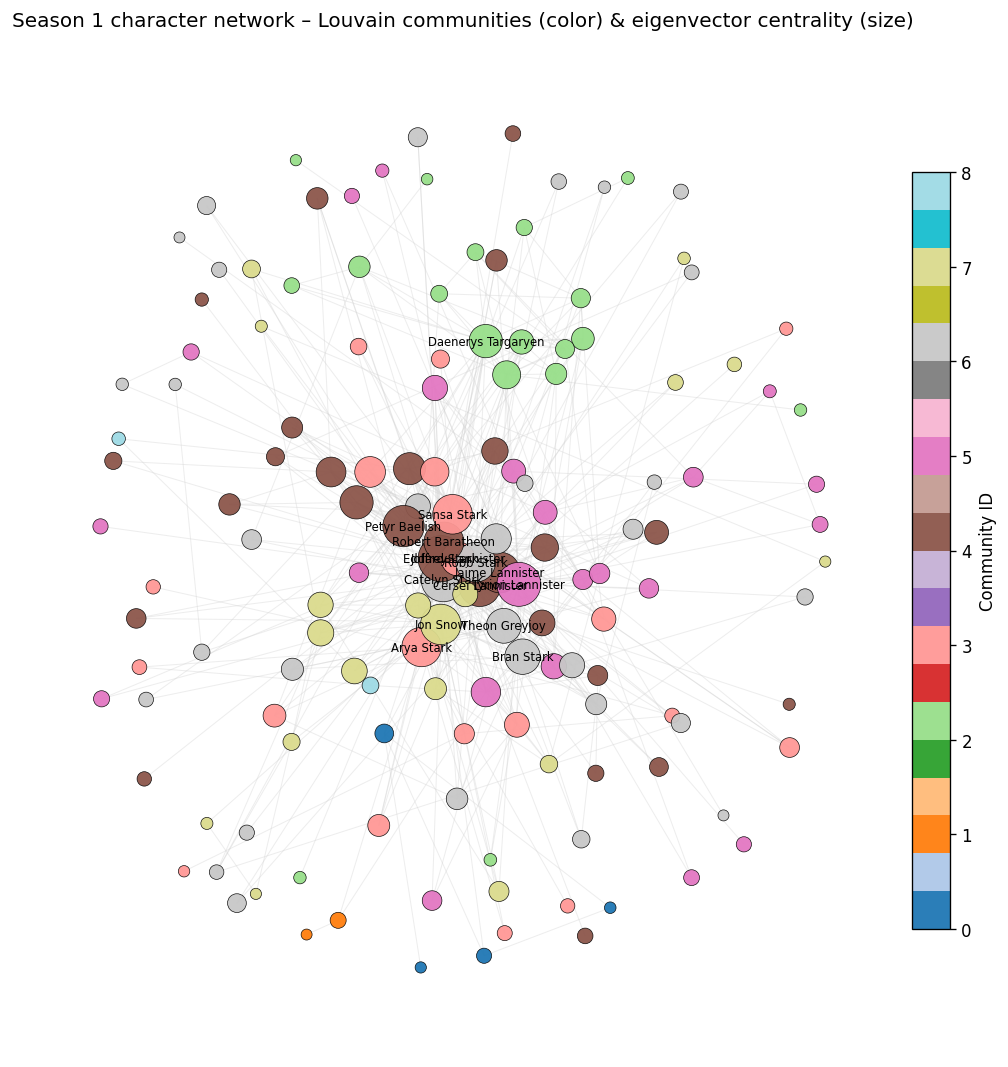

In [49]:
# ---------------------------------------------------------
# Nice-looking Season 1 network plot
# Louvain communities (color) + eigenvector centrality (size)
# ---------------------------------------------------------

# Compute layout once (slightly stronger repulsion -> clearer structure)
pos = nx.spring_layout(G_s1, seed=42, k=0.9)

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_facecolor("white")

# --- Colors by community ---
communities = pd.Series(partition)
unique_coms = sorted(communities.unique())
# Map each community id to an index [0..n-1] for the colormap
com_to_idx = {c: i for i, c in enumerate(unique_coms)}
node_colors = [com_to_idx[partition[n]] for n in G_s1.nodes()]

# --- Sizes by eigenvector centrality (scaled nicely) ---
node_sizes = [40 + 2500 * eig_c[n] for n in G_s1.nodes()]

# Draw edges first (light, so nodes stand out)
nx.draw_networkx_edges(
    G_s1,
    pos,
    ax=ax,
    edge_color="lightgray",
    width=0.6,
    alpha=0.4,
)

# Draw nodes
nodes = nx.draw_networkx_nodes(
    G_s1,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    alpha=0.95,
    edgecolors="black",
    linewidths=0.4,
)

# Label only the top-k eigenvector nodes to avoid clutter
k_label = 15
top_eig = sorted(eig_c.items(), key=lambda x: x[1], reverse=True)[:k_label]
labels = {n: n for n, _ in top_eig}

nx.draw_networkx_labels(
    G_s1,
    pos,
    labels=labels,
    ax=ax,
    font_size=7,
    font_weight="normal",
)

# Title + clean axes
ax.set_title(
    "Season 1 character network – Louvain communities (color) & eigenvector centrality (size)",
    fontsize=12,
    pad=12,
)
ax.axis("off")

# Colorbar for communities
cbar = fig.colorbar(nodes, ax=ax, shrink=0.75, pad=0.01)
cbar.set_label("Community ID", fontsize=10)

plt.tight_layout()

# --- Save for the report ---
fig.savefig("../report/fig_network.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


In [50]:
# ---------------------------------------------------------
# Simple weighted backbone (top 25% strongest edges)
# ---------------------------------------------------------

# Convert graph to edge list. If a 'weight' attribute exists it will be used;
# otherwise, we create a dummy weight = 1.
edges_df = nx.to_pandas_edgelist(G_s1)

if "weight" not in edges_df.columns:
    edges_df["weight"] = 1.0

print("Edge weights summary:")
display(edges_df["weight"].describe())

# Choose a quantile for backbone (e.g. top 25% strongest edges)
q = 0.75
threshold = edges_df["weight"].quantile(q)
print(f"\nUsing weight >= {threshold:.2f} as backbone threshold (top {int((1-q)*100)}% edges).")

backbone_edges = edges_df[edges_df["weight"] >= threshold]

print(f"Backbone edges: {len(backbone_edges)} out of {len(edges_df)} total edges")

# Build backbone graph
G_backbone = nx.Graph()
G_backbone.add_nodes_from(G_s1.nodes(data=True))  # keep node attributes (including community)

for _, row in backbone_edges.iterrows():
    G_backbone.add_edge(row["source"], row["target"], weight=row["weight"])

print(f"Backbone graph: {G_backbone.number_of_nodes()} nodes, {G_backbone.number_of_edges()} edges")


Edge weights summary:


count    482.000000
mean       6.304979
std       11.666731
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      108.000000
Name: weight, dtype: float64


Using weight >= 6.00 as backbone threshold (top 25% edges).
Backbone edges: 131 out of 482 total edges
Backbone graph: 146 nodes, 131 edges


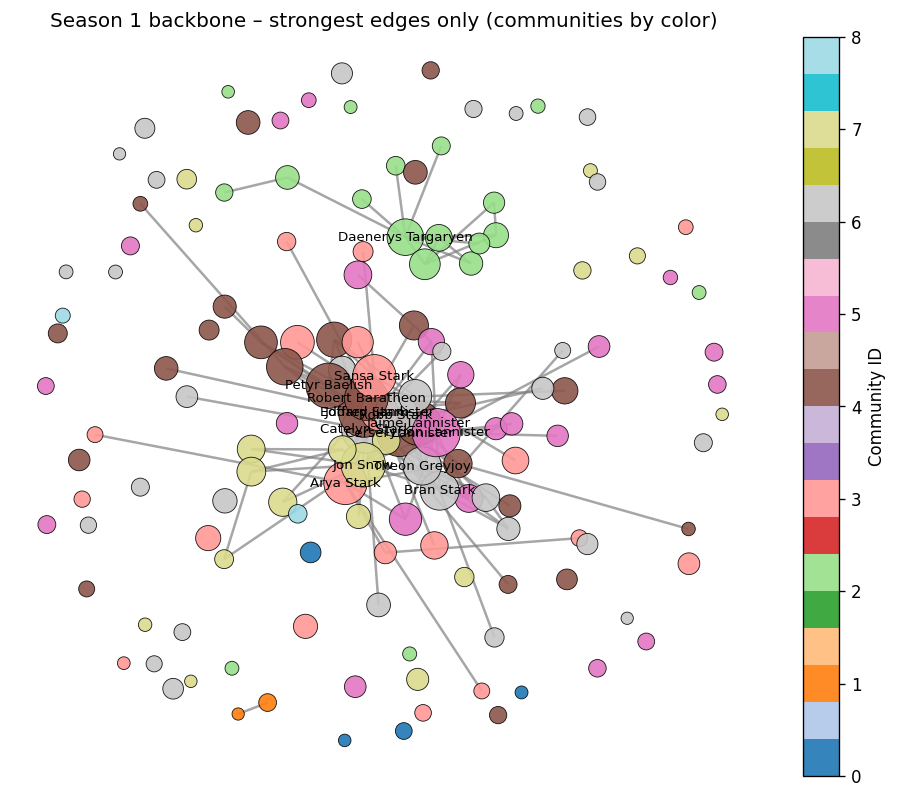

In [51]:
# ---------------------------------------------------------
# Visualise backbone with communities
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

# Reuse same positions for comparability
pos_backbone = {n: pos[n] for n in G_backbone.nodes()}

# Node colours by community again
node_colors_bb = [com_to_idx[partition[n]] for n in G_backbone.nodes()]
node_sizes_bb = [3000 * eig_c[n] + 50 for n in G_backbone.nodes()]

nodes_bb = nx.draw_networkx_nodes(
    G_backbone,
    pos_backbone,
    node_size=node_sizes_bb,
    node_color=node_colors_bb,
    cmap=plt.cm.tab20,
    alpha=0.9,
    edgecolors="black",
    linewidths=0.5,
)

nx.draw_networkx_edges(
    G_backbone,
    pos_backbone,
    alpha=0.7,
    width=1.5,
    edge_color="gray",
)

# Label only the top eigenvector nodes again
nx.draw_networkx_labels(G_backbone, pos_backbone, labels=labels, font_size=8)

plt.title("Season 1 backbone – strongest edges only (communities by color)")
plt.axis("off")
plt.colorbar(nodes_bb, label="Community ID")
plt.show()

# STEP 5 – Text + TF-IDF per community (linking language to network structure)

Now that we have a **Season 1 character network** with **communities** (Louvain) and
**centralities**, we want to connect this to the **text** of the script.

Later we can:
- Turn these top words into **wordclouds**.
- Compare **genres / houses / factions** with communities.
- Combine with **sentiment** (LabMT).


In [53]:
# Text + TF-IDF per community

print("Season 1 script shape:", s1_df.shape)
print(s1_df.head(3))

Season 1 script shape: (3179, 6)
  Release Date    Season    Episode     Episode Title          Name  \
0   2011-04-17  Season 1  Episode 1  Winter is Coming  waymar royce   
1   2011-04-17  Season 1  Episode 1  Winter is Coming          will   
2   2011-04-17  Season 1  Episode 1  Winter is Coming  waymar royce   

                                            Sentence  
0  What do you expect? They're savages. One lot s...  
1  I've never seen wildlings do a thing like this...  
2                             How close did you get?  


In [54]:
# ---------------------------------------------------------
# Normalise speaker names to match G_s1 node names
# ---------------------------------------------------------

def clean_name(name):
    """Normalise character names to match network nodes (strip + title-case)."""
    if pd.isna(name):
        return None
    name = str(name).strip()
    name = re.sub(r"\s+", " ", name)  # collapse multiple spaces
    return name.title()

# Column with the original speaker name may be 'Name' (from Game_of_Thrones_Script.csv).
# Adjust if your column has a slightly different name.
s1_df["speaker"] = s1_df["Name"].apply(clean_name)

# Also ensure we have a clean text column (Sentence/Dialogue)
text_col = "Sentence" 
s1_df[text_col] = s1_df[text_col].astype(str)

In [55]:
# ---------------------------------------------------------
# Aggregate dialogue per character (Season 1)
# ---------------------------------------------------------

# 1 document per character = concatenation of all their lines
char_text_df = (
    s1_df
    .groupby("speaker")[text_col]
    .apply(lambda s: " ".join(s))
    .reset_index()
    .rename(columns={text_col: "text"})
)

print("\nNumber of unique speakers in Season 1 script:", len(char_text_df))

# Keep only characters that appear in the Season 1 interaction network G_s1
char_text_df = char_text_df[char_text_df["speaker"].isin(G_s1.nodes())].copy()

print("Speakers after matching with network nodes:", len(char_text_df))
print(char_text_df.head(5))


Number of unique speakers in Season 1 script: 146
Speakers after matching with network nodes: 146
          speaker                                               text
0         A Voice                       It's Maester Luwin, my lord.
1  Addam Marbrand  ls it true about Stannis and Renly? Kevan Lann...
2             All  Sword! Sword! Sword! Sword! Sword! Sword! Swor...
3  Alliser Thorne  If that were a real sword, you'd be dead. Lord...
4      Arya Stark  Move! Where's the Imp? Arya. That's Jaime Lann...


In [56]:
# ---------------------------------------------------------
# Attach community labels to characters
# ---------------------------------------------------------

# communities_df was created
# columns: ['speaker', 'community', 'deg_centrality', 'btw_centrality', 'eig_centrality']

# Merge text with community + centralities
char_with_com_df = char_text_df.merge(communities_df, on="speaker", how="left")

print("\nSample: characters with community + text:")
display(char_with_com_df.head(10))

# Check if any speakers are missing a community (should be 0 if everything matches)
missing_com = char_with_com_df["community"].isna().sum()
print(f"Speakers without community label: {missing_com}")


Sample: characters with community + text:


,speaker,text,community,deg_centrality,btw_centrality,eig_centrality
0,A Voice,"It's Maester Luwin, my lord.",6,0.013793,0.000000,0.036630
1,Addam Marbrand,ls it true about Stannis and Renly? Kevan Lann...,5,0.020690,0.000039,0.008398
2,All,Sword! Sword! Sword! Sword! Sword! Sword! Swor...,6,0.027586,0.001194,0.014526
3,Alliser Thorne,"If that were a real sword, you'd be dead. Lord...",7,0.062069,0.004297,0.076239
4,Arya Stark,Move! Where's the Imp? Arya. That's Jaime Lann...,3,0.193103,0.105675,0.208039
5,Assassin,You're not supposed to be here. No one is supp...,6,0.013793,0.000000,0.031299
6,Barristan Selmy,"Of course, your Grace. A Tyroshi. Never learne...",4,0.055172,0.001224,0.091665
7,Barriston,"It was, your Grace.",4,0.006897,0.000000,0.014035
8,Benjen,Is he dead yet? You got bigger. I rode all day...,7,0.034483,0.000471,0.079080
9,Benjen Stark,Sit. You'll be fed. Untie them. Welcome. I wan...,5,0.048276,0.004017,0.076212


Speakers without community label: 0


In [57]:
# ---------------------------------------------------------
# Aggregate text per community (one document per community)
# ---------------------------------------------------------

community_text_df = (
    char_with_com_df
    .groupby("community")["text"]
    .apply(lambda s: " ".join(s))
    .reset_index()
    .sort_values("community")
    .reset_index(drop=True)
)

print("\nNumber of communities:", len(community_text_df))
print("Sample of community documents:")
display(community_text_df.head())

# For interpretation: basic size stats per community
community_size_df = (
    char_with_com_df
    .groupby("community")
    .agg(
        n_characters=("speaker", "nunique"),
        total_chars=("text", lambda s: sum(len(t) for t in s))
    )
    .reset_index()
    .sort_values("n_characters", ascending=False)
)

print("\nCommunity sizes (by number of characters and text length):")
display(community_size_df)


Number of communities: 9
Sample of community documents:


,community,text
0,0,We should head back to the wall. Our orders we...
1,1,"Watch yourself, midget. What's a gutter rat li..."
2,2,Blood of my blood… We've been his guests for o...
3,3,Move! Where's the Imp? Arya. That's Jaime Lann...
4,4,"Of course, your Grace. A Tyroshi. Never learne..."



Community sizes (by number of characters and text length):


,community,n_characters,total_chars
6,6,33,27833
4,4,27,73451
5,5,22,30774
3,3,20,18051
2,2,18,22945
7,7,18,19924
0,0,4,1223
1,1,2,536
8,8,2,457


In [58]:
# ---------------------------------------------------------
# TF-IDF on community documents  
# ---------------------------------------------------------

# Build stopword list 
stop_words = list(stopwords.words("english"))  

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=stop_words,  
    max_features=5000,       
    min_df=2                 
)

X = vectorizer.fit_transform(community_text_df["text"])
vocab = np.array(vectorizer.get_feature_names_out())

print("\nTF-IDF matrix shape (n_communities x vocab_size):", X.shape)



TF-IDF matrix shape (n_communities x vocab_size): (9, 1424)


In [59]:
# ---------------------------------------------------------
# Inspect top TF-IDF words per community
# ---------------------------------------------------------

def top_tfidf_words_for_row(row_vector, top_k=10):
    """Return the top_k words and their scores for a single TF-IDF row."""
    # Convert sparse row to dense 1D array
    arr = row_vector.toarray().ravel()
    if arr.sum() == 0:
        return []
    # Indices of top_k scores
    top_idx = arr.argsort()[::-1][:top_k]
    return list(zip(vocab[top_idx], arr[top_idx]))

print("\n=== Top TF-IDF words per community ===\n")

for idx, row in community_text_df.iterrows():
    com_id = row["community"]
    row_vec = X[idx]
    
    # Get size info to print next to community
    size_row = community_size_df[community_size_df["community"] == com_id].iloc[0]
    n_chars = size_row["n_characters"]
    
    top_words = top_tfidf_words_for_row(row_vec, top_k=10)
    
    print(f"Community {com_id}  (n_characters = {n_chars})")
    print("----------------------------------------")
    if not top_words:
        print("  (No distinctive words – TF-IDF row is empty)")
    else:
        for w, score in top_words:
            print(f"  {w:15s}  {score:.3f}")
    print()




=== Top TF-IDF words per community ===

Community 0  (n_characters = 4)
----------------------------------------
  walkers          0.351
  white            0.351
  saw              0.284
  back             0.227
  get              0.227
  know             0.227
  deserter         0.178
  us               0.170
  thing            0.170
  lot              0.157

Community 1  (n_characters = 2)
----------------------------------------
  sword            0.574
  give             0.287
  look             0.287
  squire           0.265
  like             0.259
  better           0.191
  kept             0.172
  rat              0.172
  stole            0.172
  knocked          0.172

Community 2  (n_characters = 18)
----------------------------------------
  khal             0.342
  dragon           0.315
  drogo            0.250
  dothraki         0.228
  want             0.175
  like             0.125
  know             0.124
  go               0.113
  men              0.112
  take      

### Wordclouds for communities (based on TF-IDF)

To get a more visual feeling of what each community “talks about”, we will create
**wordclouds** for the top communities, using TF-IDF weights as word frequencies.



We will then  plot 4–6 communities (depending on how many we kept in `community_text_df`).


Will plot wordclouds for communities: [6, 4, 5, 3]


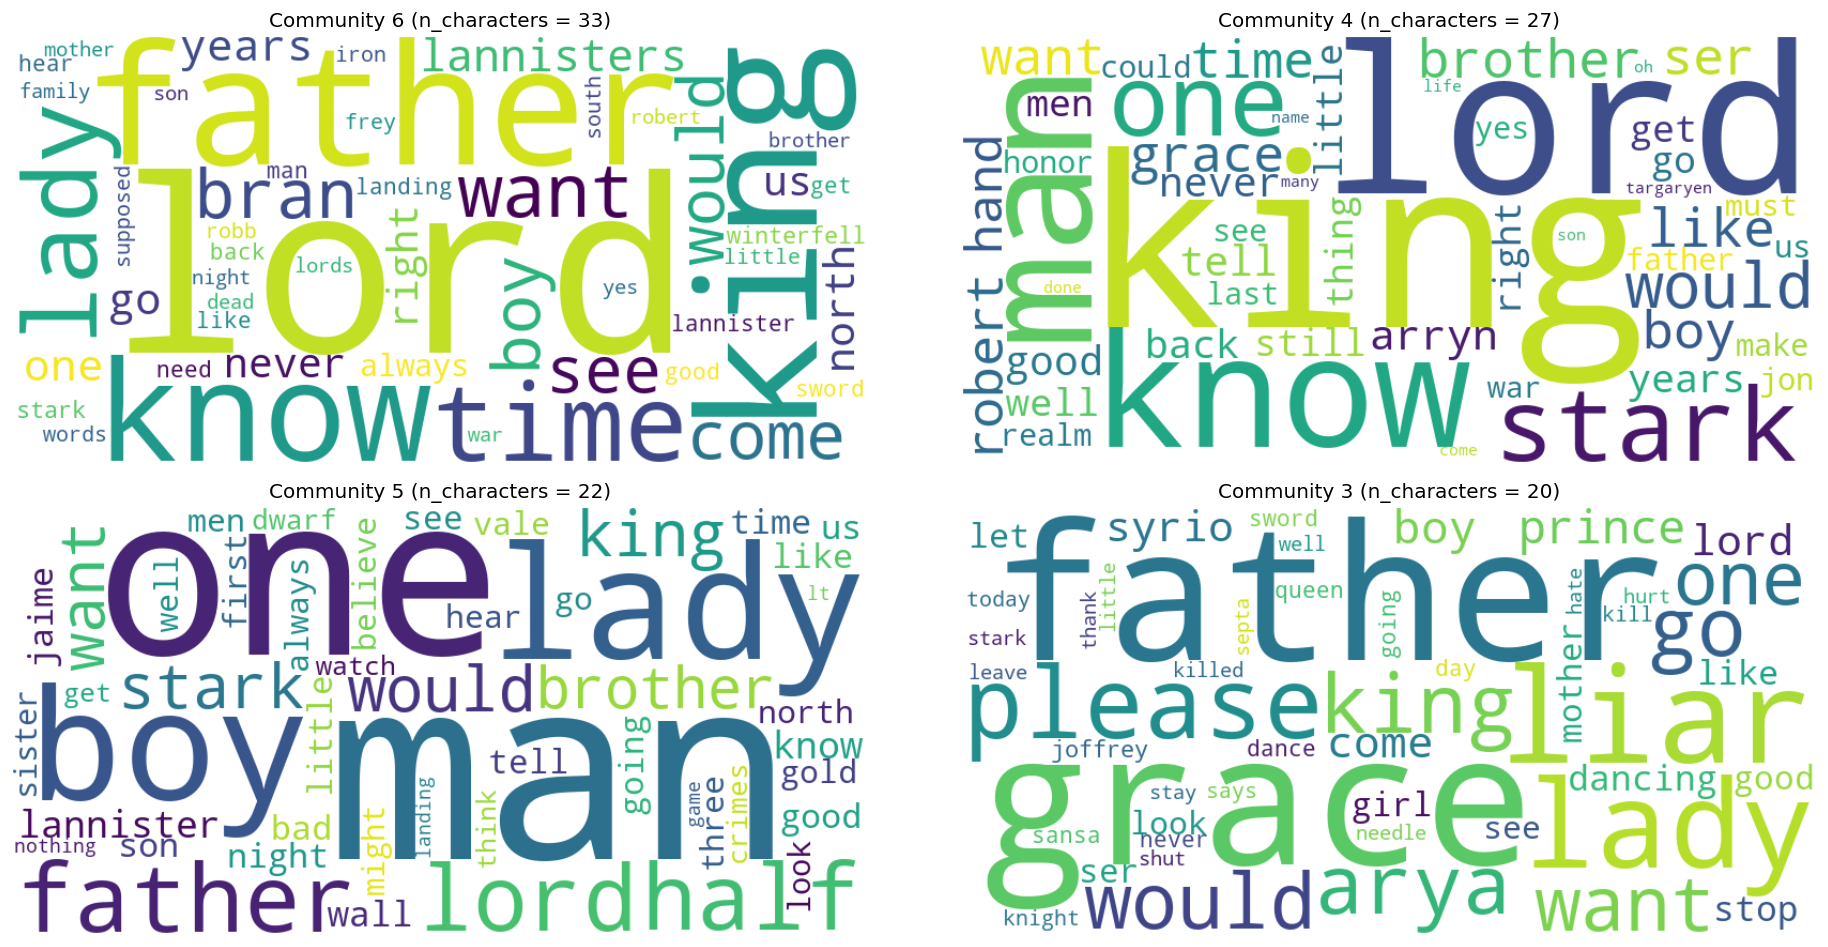

In [61]:
# 5.8 Wordclouds from TF–IDF per community
# ----------------------------------------
community_top_words = {}
n_words_for_cloud = 50

for idx, row in community_text_df.iterrows():
    com_id = row["community"]
    row_vec = X[idx]
    top_pairs = top_tfidf_words_for_row(row_vec, top_k=n_words_for_cloud)
    freqs = {w: float(score) for w, score in top_pairs}
    community_top_words[com_id] = freqs

communities_to_plot = (
    community_size_df
    .sort_values("n_characters", ascending=False)
    .head(4)["community"]
    .tolist()
)

print("Will plot wordclouds for communities:", communities_to_plot)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.ravel()

for i, com_id in enumerate(communities_to_plot):
    freqs = community_top_words.get(com_id, {})
    if not freqs:
        continue

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="viridis",
    ).generate_from_frequencies(freqs)

    ax = axes[i]
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")

    n_chars = int(
        community_size_df.loc[community_size_df["community"] == com_id, "n_characters"].iloc[0]
    )
    ax.set_title(f"Community {com_id} (n_characters = {n_chars})")

fig.tight_layout()
fig.savefig("../report/fig_wordclouds.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


# Step 6. Sentiment with LabMT per community

We now add **sentiment analysis using LabMT**.



LabMT is a lexicon where each word has a **happiness score** (typically 1–9):
- ~5 is “neutral”.
- more than 5 is more positive.
- less than 5 is more negative.


In the next steps, we can:
- Make bar plots of sentiment per community.
- Compare sentiment with centrality / TF–IDF.


In [63]:
# ---------------------------------------------------------
# Sentiment with LabMT per community
# ---------------------------------------------------------



LABMT_PATH = "../data/LabMT_english.csv"


# 1) Load the LabMT CSV
labmt = pd.read_csv(LABMT_PATH)

print("Loaded LabMT file with columns:")
print(labmt.columns.tolist())
print()

# 2) Manually specify the word and happiness-score columns
word_col = "Word"              # column containing the word
h_col    = "Happiness Score"   # column containing the happiness score

# make sure the columns exist
if word_col not in labmt.columns or h_col not in labmt.columns:
    raise ValueError(
        f"Could not find '{word_col}' or '{h_col}' in LabMT columns. "
        f"Available columns: {labmt.columns.tolist()}"
    )

print(f"Using LabMT word column      : {word_col}")
print(f"Using LabMT happiness column : {h_col}")
print()

# 3) Build a compact DataFrame with just word + score
labmt_df = labmt[[word_col, h_col]].copy()

# 4) Lowercase all words to standardise matching
labmt_df[word_col] = labmt_df[word_col].astype(str).str.lower()

# 5) Build a dictionary: word -> happiness score
labmt_scores = dict(zip(labmt_df[word_col], labmt_df[h_col]))

print(f"Built LabMT dictionary with {len(labmt_scores)} word scores.")
# quick peek at a few entries
sample_items = list(labmt_scores.items())[:10]
print("Sample LabMT entries:", sample_items)


Loaded LabMT file with columns:
['Rank', 'Word', 'Word in English', 'Happiness Score', 'Standard Deviation of Ratings']

Using LabMT word column      : Word
Using LabMT happiness column : Happiness Score

Built LabMT dictionary with 10222 word scores.
Sample LabMT entries: [('laughter', 8.5), ('happiness', 8.44), ('love', 8.42), ('happy', 8.3), ('laughed', 8.26), ('laugh', 8.22), ('laughing', 8.2), ('excellent', 8.18), ('laughs', 8.18), ('joy', 8.16)]


In [64]:
# ---------------------------------------------------------
# Build a cleaned LabMT lexicon (filter out neutral words)
# ---------------------------------------------------------

# LabMT is usually centered around 5.0 as neutral
neutral_center = 5.0

# Compute deviation from neutral sentiment
labmt["deviation"] = labmt[h_col] - neutral_center

# Keep only "strong" sentiment words 
# we can tune this threshold: 0.5, 1.0, etc.
threshold = 1.0
labmt_strong = labmt[np.abs(labmt["deviation"]) >= threshold].copy()

print(f"LabMT entries total   : {len(labmt)}")
print(f"Strong sentiment words: {len(labmt_strong)} (|deviation| >= {threshold})")

# Build dictionary: word -> deviation
labmt_lexicon = dict(
    zip(labmt_strong[word_col].astype(str).str.lower(), labmt_strong["deviation"])
)

LabMT entries total   : 10222
Strong sentiment words: 3731 (|deviation| >= 1.0)


In [65]:
# ---------------------------------------------------------
# function to compute LabMT sentiment for a text
# ---------------------------------------------------------

token_pattern = re.compile(r"[a-z]+")

def labmt_sentiment_score(text):
    """
    Compute average LabMT sentiment deviation for a text.
    Positive value  -> more positive than neutral.
    Negative value  -> more negative than neutral.
    Zero / NaN      -> neutral / no matching words.
    """
    if not isinstance(text, str):
        return np.nan
    
    # Lowercase + simple word tokenization
    tokens = token_pattern.findall(text.lower())
    if not tokens:
        return np.nan
    
    # Collect LabMT deviations for words that exist in the lexicon
    vals = [labmt_lexicon[w] for w in tokens if w in labmt_lexicon]
    if not vals:
        # No sentiment words found → treat as neutral
        return 0.0
    
    return float(np.mean(vals))

In [66]:
# ---------------------------------------------------------
# 6.4 Apply LabMT sentiment to each community document
# ---------------------------------------------------------

# We assume you already have community_text_df from previous steps:
# - columns: ["community", "n_characters", "text"]

community_text_df["labmt_sentiment"] = community_text_df["text"].apply(
    labmt_sentiment_score
)

# Merge with size info for convenience
community_sentiment_df = community_text_df.merge(
    community_size_df[["community", "n_characters"]], on="community", how="left"
)

# Sort by sentiment (from most positive to most negative)
community_sentiment_df = community_sentiment_df.sort_values(
    "labmt_sentiment", ascending=False
).reset_index(drop=True)

print("\n=== LabMT sentiment per community (Season 1) ===")
display(
    community_sentiment_df[["community", "n_characters", "labmt_sentiment"]]
)


=== LabMT sentiment per community (Season 1) ===


,community,n_characters,labmt_sentiment
0,8,2,0.964783
1,5,22,0.927597
2,6,33,0.861132
3,2,18,0.855316
4,4,27,0.851539
5,7,18,0.844500
6,3,20,0.797616
7,0,4,0.674462
8,1,2,0.292414


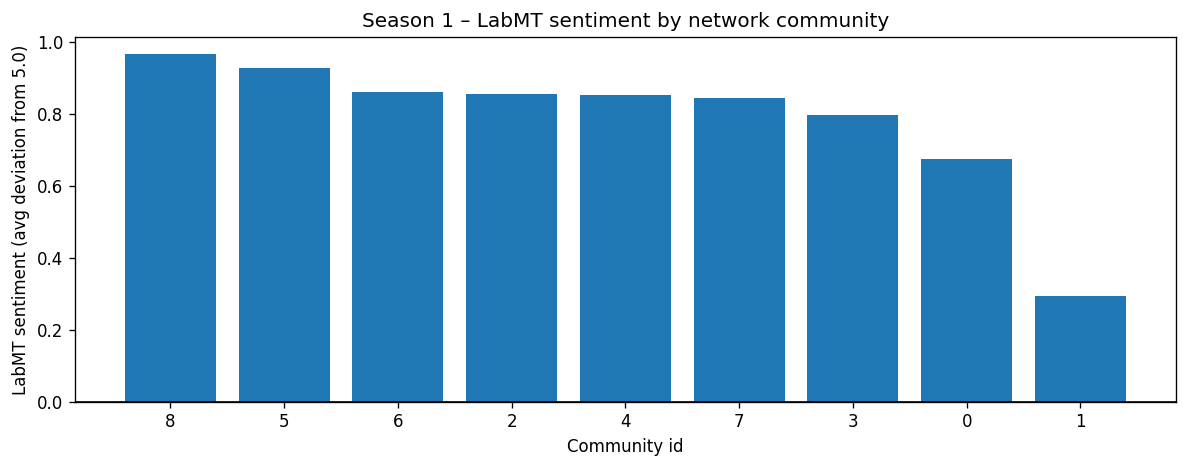

In [67]:
# ---------------------------------------------------------
# bar plot: sentiment per community
# ---------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.bar(
    community_sentiment_df["community"].astype(str),
    community_sentiment_df["labmt_sentiment"],
)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Community id")
plt.ylabel("LabMT sentiment (avg deviation from 5.0)")
plt.title("Season 1 – LabMT sentiment by network community")
plt.tight_layout()
plt.show()


In [68]:
# ---------------------------------------------------------
# 6.2 Compute LabMT sentiment per Louvain community
#      → DataFrame: community_sentiment_full
# ---------------------------------------------------------

# We assume we already have:
# - community_text_df   (columns: at least: community, text)
# - community_size_df   (columns: community, n_characters, ...)
# - labmt_scores        (dict: word -> happiness score, 1..9)


def tokenize_simple(text):
    """
    Very simple tokenizer:
    - lowercase
    - keep only alphabetic + apostrophes
    - returns a list of tokens
    """
    if not isinstance(text, str):
        return []
    text = text.lower()
    # words like don't, king's → keep as single tokens
    return re.findall(r"[a-z']+", text)


def sentiment_from_tokens(tokens, labmt_dict):
    """
    Given a list of tokens and a LabMT dictionary (word -> score),
    return:
      mean_raw, mean_shifted, n_scored, n_tokens, coverage
    """
    if not tokens:
        return np.nan, np.nan, 0, 0, 0.0

    scores = [labmt_dict[w] for w in tokens if w in labmt_dict]

    n_tokens = len(tokens)
    n_scored = len(scores)

    if n_scored == 0:
        return np.nan, np.nan, 0, n_tokens, 0.0

    mean_raw = float(np.mean(scores))          # average 1..9
    mean_shifted = mean_raw - 5.0              # center around 0
    coverage = n_scored / n_tokens

    return mean_raw, mean_shifted, n_scored, n_tokens, coverage


sent_rows = []

# Check if n_lines exists in community_text_df
has_n_lines = "n_lines" in community_text_df.columns

for _, row in community_text_df.iterrows():
    com_id = row["community"]
    text = row["text"]
    
    # if n_lines column exists, use it; otherwise set NaN
    n_lines = row["n_lines"] if has_n_lines else np.nan

    tokens = tokenize_simple(text)
    mean_raw, mean_shifted, n_scored, n_tokens, coverage = sentiment_from_tokens(
        tokens, labmt_scores
    )

    sent_rows.append({
        "community"    : com_id,
        "mean_raw"     : mean_raw,
        "mean_shifted" : mean_shifted,
        "n_scored"     : n_scored,
        "n_tokens"     : n_tokens,
        "coverage"     : coverage,
        "n_lines"      : n_lines,
    })

community_sentiment = pd.DataFrame(sent_rows)

# Merge with community_size_df to add number of characters per community
community_sentiment_full = community_sentiment.merge(
    community_size_df[["community", "n_characters"]],
    on="community",
    how="left"
)

print("=== Community sentiment summary (first rows) ===")
display(community_sentiment_full.head())

print("\nNumber of communities with non-NaN mean_shifted:",
      community_sentiment_full["mean_shifted"].notna().sum())


=== Community sentiment summary (first rows) ===


,community,mean_raw,mean_shifted,n_scored,n_tokens,coverage,n_lines,n_characters
0,0,5.347456,0.347456,228,245,0.930612,NaN,4
1,1,5.216822,0.216822,107,112,0.955357,NaN,2
2,2,5.430212,0.430212,4109,4495,0.914127,NaN,18
3,3,5.420930,0.420930,3279,3501,0.936590,NaN,20
4,4,5.419473,0.419473,12913,14022,0.920910,NaN,27



Number of communities with non-NaN mean_shifted: 9


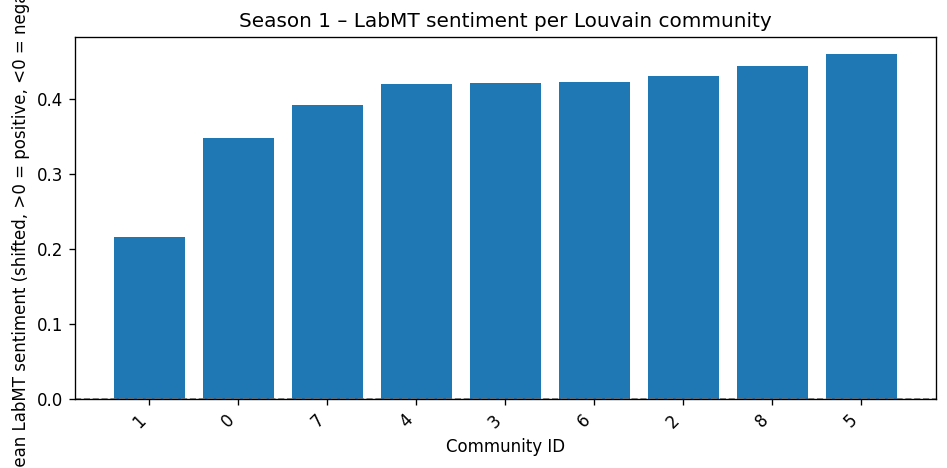

Plotted 9 communities with non-NaN sentiment.


In [69]:
# ---------------------------------------------------------
# Plot LabMT sentiment per community
# ---------------------------------------------------------

# Filter to communities where we actually have a mean_shifted value
sent_plot_df = community_sentiment_full.dropna(subset=["mean_shifted"]).copy()

# Sort by sentiment (from saddest to happiest)
sent_plot_df = sent_plot_df.sort_values(by="mean_shifted", ascending=True)

import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(sent_plot_df))

ax.bar(
    x,
    sent_plot_df["mean_shifted"],
)

ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)

ax.set_xlabel("Community ID")
ax.set_ylabel("Mean LabMT sentiment (shifted, >0 = positive, <0 = negative)")
ax.set_title("Season 1 – LabMT sentiment per Louvain community")

ax.set_xticks(x)
ax.set_xticklabels(sent_plot_df["community"].astype(str), rotation=45, ha="right")

fig.tight_layout()
fig.savefig("../report/fig_sentiment.pdf", dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

print("Plotted", len(sent_plot_df), "communities with non-NaN sentiment.")


Using the LabMT scores, we computed the average sentiment of each Louvain community in the Season 1 character network. All communities have a positive shifted sentiment (> 0), meaning that, on average, their dialogue is slightly more positive than neutral. However, there is noticeable variation: community 5 and community 1 show the highest sentiment values (≈ 0.48 and 0.46), while community

# STEP 7 – Link communities, main characters, and sentiment (fixed to our columns)

For each community, build a compact summary with:

   - number of characters
   - mean LabMT sentiment
   - top 5 characters by degree

We store this in `community_overview_df` and also print a text summary that is easy to reuse in the report.


In [72]:
# Link communities, main characters, and LabMT sentiment



# --- 1) Make sure we have community labels for each node in nodes_df ---

# We assume:
# - G_s1 is the Season 1 undirected character graph
# - nodes_df has at least: ['id', 'label', 'n_lines',
#                           'degree_centrality', 'betweenness_centrality',
#                           'eigenvector_centrality']

# If "community" is missing, build it from Louvain partition
if "community" not in nodes_df.columns:
    try:
        # If you still have the partition dict from earlier
        nodes_df["community"] = nodes_df["label"].map(partition).astype(int)
        print("Added 'community' to nodes_df from existing 'partition' dict.")
    except NameError:
        # Recompute Louvain on G_s1 if partition is not defined
        print("No existing 'partition' found – recomputing Louvain on G_s1.")
        import community as community_louvain

        partition = community_louvain.best_partition(G_s1)
        nodes_df["community"] = nodes_df["label"].map(partition).astype(int)
        print("Added 'community' to nodes_df from new Louvain partition.")

# --- 2) Add an integer degree column (for ranking characters) ---

if "degree" not in nodes_df.columns:
    # Build a dict: character label -> degree in G_s1
    deg_dict = dict(G_s1.degree())
    nodes_df["degree"] = nodes_df["label"].map(deg_dict).fillna(0).astype(int)
    print("Added 'degree' column to nodes_df from G_s1.")

print("\nnodes_df head after adding community + degree:")
print(nodes_df.head())

# --- 3) Merge character-level info with community-level sentiment ---

print("\ncommunity_sentiment_full columns:",
      community_sentiment_full.columns.tolist())

nodes_with_sentiment = nodes_df.merge(
    community_sentiment_full[["community", "mean_shifted", "n_characters"]],
    on="community",
    how="left"
)

print("\nMerged nodes_with_sentiment (first rows):")
print(nodes_with_sentiment.head())

# --- 4) Build a compact overview table: one row per community ---

overview_rows = []
TOP_K = 5  # how many top characters to list per community

for com_id in sorted(nodes_with_sentiment["community"].unique()):
    sub = nodes_with_sentiment[nodes_with_sentiment["community"] == com_id].copy()
    
    # Sort characters by degree (most connected first)
    sub = sub.sort_values("degree", ascending=False)

    # Top-k character names
    top_chars = sub["label"].head(TOP_K).tolist()
    
    # Community-level numbers
    n_chars_graph = len(sub)
    mean_sent = sub["mean_shifted"].iloc[0]
    n_chars_sent = sub["n_characters"].iloc[0]  # from community_sentiment_full

    overview_rows.append({
        "community": com_id,
        "n_characters_in_graph": n_chars_graph,
        "n_characters_sentiment": n_chars_sent,
        "mean_labmt_shifted": mean_sent,
        "top_characters": ", ".join(top_chars),
    })

community_overview_df = (
    pd.DataFrame(overview_rows)
    .sort_values(by="mean_labmt_shifted", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Community overview: structure + sentiment ===")
print(community_overview_df)

# --- 5) Narrative-style summary  ---

print("\n=== Text summary per community ===\n")
for _, row in community_overview_df.iterrows():
    com_id = row["community"]
    n_chars = row["n_characters_in_graph"]
    mean_sent = row["mean_labmt_shifted"]
    tops = row["top_characters"]
    
    print(f"Community {com_id}:")
    print(f"  - {n_chars} characters")
    print(f"  - mean LabMT sentiment (shifted) ≈ {mean_sent:.3f}")
    print(f"  - top characters by degree: {tops}")
    print("-" * 80)


Added 'community' to nodes_df from existing 'partition' dict.
Added 'degree' column to nodes_df from G_s1.

nodes_df head after adding community + degree:
               id           label  n_lines  degree_centrality  \
0         A Voice         A Voice        1           0.013793   
1  Addam Marbrand  Addam Marbrand        2           0.020690   
2             All             All        2           0.027586   
3  Alliser Thorne  Alliser Thorne       13           0.062069   
4      Arya Stark      Arya Stark      102           0.193103   

   betweenness_centrality  eigenvector_centrality  community  degree  
0                0.000000                0.036630          6       2  
1                0.000039                0.008398          5       3  
2                0.001194                0.014526          6       4  
3                0.004297                0.076239          7       9  
4                0.105675                0.208039          3      28  

community_sentiment_full co

#  Results

For **Game of Thrones – Season 1** we find that:

- The **character network** is one giant component with clear **Louvain communities** matching story factions (Starks, King’s Landing, Night’s Watch, Daenerys/Dothraki, etc.).
- **Centralities** (degree, betweenness, eigenvector) pick out the expected main characters: Eddard, Catelyn, Tyrion, Cersei, Jon, Robb, Robert.
- Community-level **TF–IDF** shows distinct vocabularies per faction (court politics, war camp, the Wall, Essos/Dothraki).
- **LabMT sentiment** shows small but consistent differences: political/war groups are slightly less positive than other storylines.

Overall, **structure (graph), topics (TF–IDF), and mood (LabMT)** all align with the narrative factions of Season 1.





This notebook shows a simple, reproducible pipeline (NetworkX + NLTK + TF–IDF + LabMT) that links **who talks to whom**, **what they say**, and **how positive/negative it is** for only Season 1.   

